# Multi-class Text Classification Experiment - Experimenting with Different Methods

This notebook will build on the work done in the binary sentiment analysis notebook that experimented with different methods of separating text into 2 categories. Instead this time we will do multi-class classification instead of binary classification. Our data will come from Kaggle and be on news article topics. You can find the dataset [here on Kaggle.](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset?select=test.csv)

In [1]:
import os
import re
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM
from IPython.core.magic import register_cell_magic
from sklearn.metrics import f1_score

In [2]:
# Initialize df to log performance metrics
execution_df = pd.DataFrame(columns=["Cell_Label", "Execution_Time_Sec"])

# This function will be used to log the execution time of each cell in the notebook for which it is run with. 
@register_cell_magic
def log_time(line, cell):
    global execution_df
    # Use the string passed next to the magic command as the cell label
    label = line.strip() if line.strip() else f"Cell_{len(execution_df) + 1}"

    start_time = time.perf_counter()
    shell = get_ipython()
    shell.run_cell(cell)
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    new_row = pd.DataFrame([{"Cell_Label": label, "Execution_Time_Sec": elapsed_time}])
    execution_df = pd.concat([execution_df, new_row], ignore_index=True)


In [3]:
results_df = pd.DataFrame({}, columns=["Method", "Accuracy", "F1-Micro"])

In [4]:
train_df = pd.read_csv('train.csv') 
val_df = pd.read_csv('test.csv') 
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
# Saving the mapping of class indices to class names for later use
class_map = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

We see each dataset contains 3 columns, we will concatenate the title to the description.

In [6]:
train_df["text"] = train_df["Title"] + " - " + train_df["Description"]
val_df["text"] = val_df["Title"] + " - " + val_df["Description"]
train_df = train_df.rename(columns={'Class Index': 'label'})
val_df = val_df.rename(columns={'Class Index': 'label'})

train_df = train_df[["text", "label"]]
val_df = val_df[["text", "label"]]


In [7]:
train_df.shape

(120000, 2)

In [8]:
train_df["label"].value_counts()

label
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [9]:
val_df.shape

(7600, 2)

In [10]:
val_df["label"].value_counts()

label
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64

We see the the classes are balanced, so no need to sample.

Lastly we will encode the pos/neg labels as numeric values and we will apply some text cleaning to standardize text. 

In [11]:
train_df

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,3
1,Carlyle Looks Toward Commercial Aerospace (Reu...,3
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,3
3,Iraq Halts Oil Exports from Main Southern Pipe...,3
4,"Oil prices soar to all-time record, posing new...",3
...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,1
119996,Renteria signing a top-shelf deal - Red Sox ge...,2
119997,Saban not going to Dolphins yet - The Miami Do...,2
119998,Today's NFL games - PITTSBURGH at NY GIANTS Ti...,2


We will also run some universal text cleaning to standardize the way that text is presented. This is important for more primitive feature collection methods. 

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_clean'] = train_df['text'].apply(clean_text)
val_df['text_clean'] = val_df['text'].apply(clean_text)

## Method 1: Bag of Words with Decision Tree
The most primitive way to turn our text into numeric features to use for prediction would be to use a "bag of words" approach where each word in the text becomes a column value and we count the number of times it appears in the sequence. 

In [13]:
y_train = train_df['label']
y_val = val_df['label']

In [14]:
%%time
%%log_time Method1_BoWTraining
vectorizer = CountVectorizer(stop_words='english', min_df=2)

X_train = vectorizer.fit_transform(train_df['text_clean'])
X_val = vectorizer.transform(val_df['text_clean'])
bow_model = DecisionTreeClassifier(max_depth=10, random_state=42)
bow_model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

CPU times: user 1.54 s, sys: 25 ms, total: 1.57 s
Wall time: 1.58 s


In [15]:
%%time
%%log_time Method1_BoWInference
y_pred = bow_model.predict(X_val)

CPU times: user 1.35 ms, sys: 601 μs, total: 1.95 ms
Wall time: 1.3 ms


In [16]:
print('Validation classification report:')
print(classification_report(y_val, y_pred))

Validation classification report:
              precision    recall  f1-score   support

           1       0.88      0.38      0.53      1900
           2       0.93      0.27      0.42      1900
           3       0.88      0.18      0.31      1900
           4       0.32      0.97      0.48      1900

    accuracy                           0.45      7600
   macro avg       0.75      0.45      0.43      7600
weighted avg       0.75      0.45      0.43      7600



Text(0.5, 1.0, 'BOW Model Accuracy Score: 0.45092105263157894')

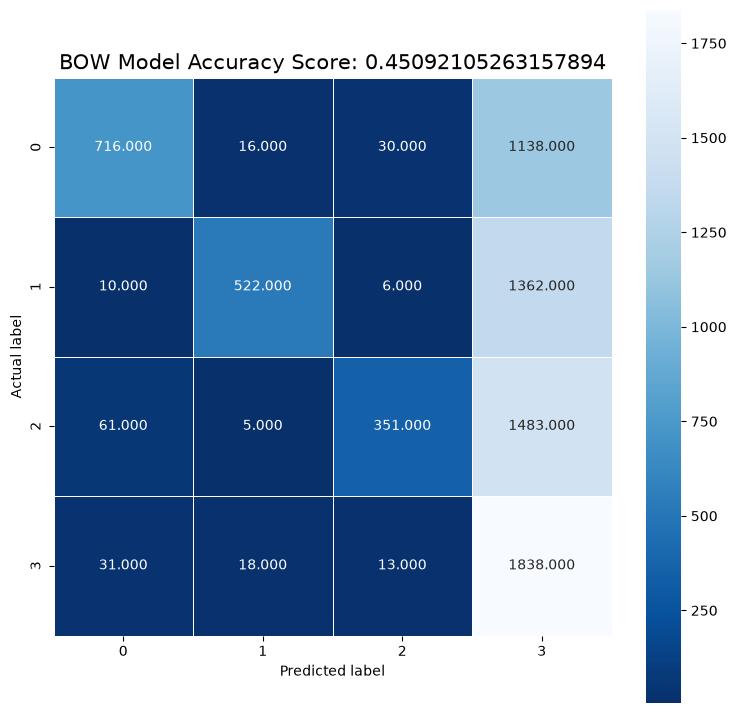

In [17]:
conf_matrix = confusion_matrix(y_val, y_pred)
acc = bow_model.score(X_val, y_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'BOW Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

In [18]:

bow_results = pd.DataFrame([{"Method": "Bag of Words", "Accuracy": acc,  "F1-Macro": macro_f1}])
results_df = pd.concat([results_df, bow_results], ignore_index=True)

Results show that using Bag-of-words features can be a viable way to give a model enough content to be intelligent, but there are ways to increase the quality of context we can provide to a model. It seems currently that with this method, the model mistakenly classifies most articles as being about science and technology. 

## Method 2: TF-IDF Vectorizer + Decision Tree
The Bag of Words approach is maybe our most simple method of capturing vocabulary, but we can improve on this. TF-IDF allows our model to understand the importance of terms that show up throughout a dataset. We will see how increasing the complexity of feature collection will affect the accuracy of prediction with the same Decision Tree model. 

In [19]:
%%time
%%log_time Method2_TFIDFTraining
tfidf = TfidfVectorizer(stop_words='english', min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df['text_clean'])
X_val_tfidf = tfidf.transform(val_df['text_clean'])

tfidf_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tfidf_model.fit(X_train_tfidf, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

CPU times: user 2.6 s, sys: 25.9 ms, total: 2.62 s
Wall time: 2.63 s


In [20]:
%%time
%%log_time Method2_TFIDFInference
y_pred_tfidf = tfidf_model.predict(X_val_tfidf)

CPU times: user 1.37 ms, sys: 782 μs, total: 2.15 ms
Wall time: 1.41 ms


In [21]:
print('TF-IDF Validation classification report:')
print(classification_report(y_val, y_pred_tfidf))


TF-IDF Validation classification report:
              precision    recall  f1-score   support

           1       0.88      0.38      0.53      1900
           2       0.93      0.28      0.42      1900
           3       0.86      0.18      0.30      1900
           4       0.31      0.96      0.47      1900

    accuracy                           0.45      7600
   macro avg       0.75      0.45      0.43      7600
weighted avg       0.75      0.45      0.43      7600



Text(0.5, 1.0, 'TF-IDF Model Accuracy Score: 0.44973684210526316')

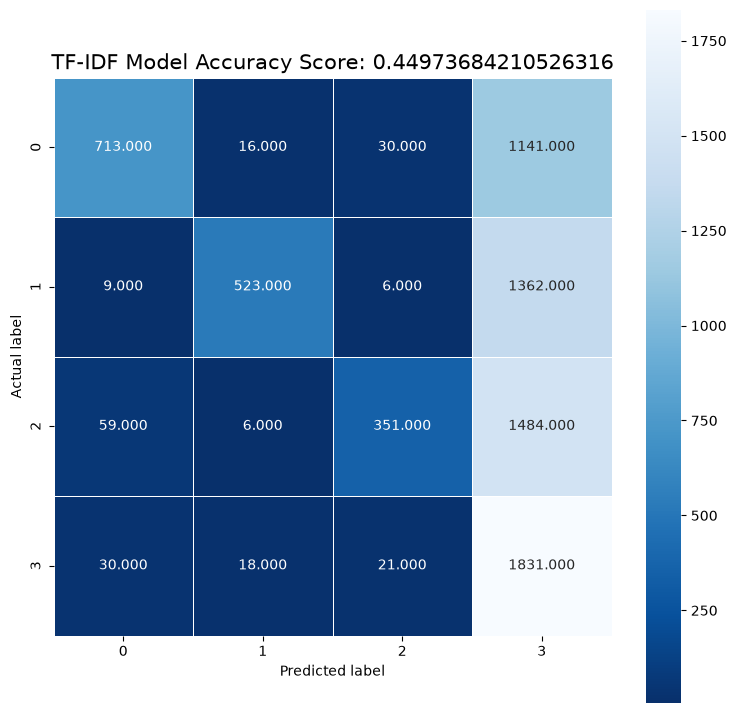

In [22]:
conf_matrix = confusion_matrix(y_val, y_pred_tfidf)
acc = tfidf_model.score(X_val_tfidf, y_val)
macro_f1 = f1_score(y_val, y_pred_tfidf, average='macro')
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'TF-IDF Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

In [23]:
tfidf_results = pd.DataFrame([{"Method": "TF-IDF", "Accuracy": acc,  "F1-Macro": macro_f1}])
results_df = pd.concat([results_df, tfidf_results], ignore_index=True)

With an out of the box TF-IDF vectorizer we actually see a decrease in performance compared to Bag-of-words. There could be greater results with a more complex TF-IDF vectorizer but we will move on to other methods. It still seems currently that with this method, the model mistakenly classifies most articles as being about science and technology. 

## Method 3: Using embeddings as features for a model
Thus far we have seen traditional feature extraction methods but with the rise of generative AI design solutions there has been a rise in using text embeddings for many NLP solutions. We will see how the use of embedding features with no other change in model affects the results. 


In [24]:
%%time
%%log_time Method3_EmbeddingTraining
# Using sentence-transformers to get embeddings for the tweets
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_train = model.encode(train_df['text_clean'].tolist(), show_progress_bar=True)
embeddings_val = model.encode(val_df['text_clean'].tolist(), show_progress_bar=True)

embedding_log_model = DecisionTreeClassifier(max_depth=10, random_state=42)
embedding_log_model.fit(embeddings_train, y_train)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3750 [00:00<?, ?it/s]

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

CPU times: user 1min 2s, sys: 11 s, total: 1min 13s
Wall time: 1min 36s


In [25]:
print('Train embeddings shape:', getattr(embeddings_train, 'shape', None))
print('Val embeddings shape:', getattr(embeddings_val, 'shape', None))

Train embeddings shape: (120000, 384)
Val embeddings shape: (7600, 384)


In [26]:
%%time
%%log_time Method3_EmbeddingInference
y_pred_embedding = embedding_log_model.predict(embeddings_val)

CPU times: user 2.61 ms, sys: 981 μs, total: 3.59 ms
Wall time: 2.88 ms


In [27]:
print('Embedding Validation classification report:')
print(classification_report(y_val, y_pred_embedding))

Embedding Validation classification report:
              precision    recall  f1-score   support

           1       0.73      0.70      0.71      1900
           2       0.82      0.81      0.81      1900
           3       0.64      0.68      0.66      1900
           4       0.67      0.68      0.67      1900

    accuracy                           0.71      7600
   macro avg       0.72      0.71      0.72      7600
weighted avg       0.72      0.71      0.72      7600



Text(0.5, 1.0, 'Embedding Model Accuracy Score: 0.7148684210526316')

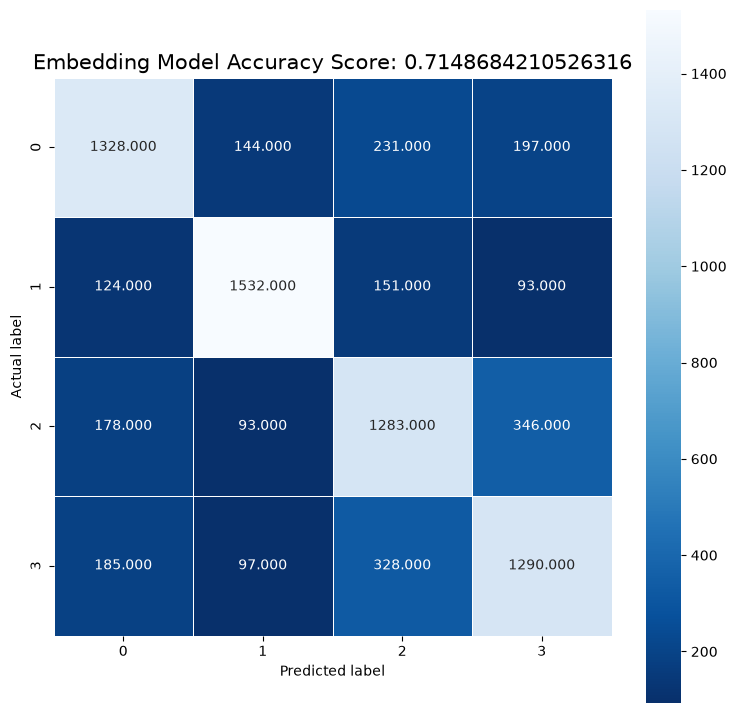

In [28]:
conf_matrix = confusion_matrix(y_val, y_pred_embedding)
acc = embedding_log_model.score(embeddings_val, y_val)
macro_f1 = f1_score(y_val, y_pred_embedding, average='macro')
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Embedding Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

In [29]:
embedding_results = pd.DataFrame([{"Method": "Embedding", "Accuracy": acc,  "F1-Macro": macro_f1}])
results_df = pd.concat([results_df, embedding_results], ignore_index=True)

We see a nice improvement here by using text embeddings alone. More complex embedding models may be able to give a classifier even more context and in turn increase the accuracy further. Using text embeddings also seems to have balanced where the model makes errors as it seems to misclassify in a mostly equal way now across classes.

## Method 4: Task Specific Model
This will be a somewhat imperfect comparison because we will test an open source model that can classify news into 40 different topics on our data which contains news with 4 topic labels. However this can still give us a good idea of how a task specific model might work on topic classification. 


In [30]:
%%time 
%%log_time Method4_TaskSpecificModelAcquisition
task_specific_model = pipeline("text-classification", model="cssupport/bert-news-class")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

CPU times: user 107 ms, sys: 102 ms, total: 210 ms
Wall time: 1.21 s


In [31]:
%%log_time Method4_TaskSpecificModelInference
y_pred_task_specific = [task_specific_model(text) for text in val_df['text']]

In [32]:
rows = []
for item in y_pred_task_specific:
    if isinstance(item, list):
        top = item[0] if len(item) > 0 else {}
    elif isinstance(item, dict):
        top = item
    else:
        top = {}
    label = top.get('label') if isinstance(top, dict) else None
    score = top.get('score') if isinstance(top, dict) else None
    rows.append({'label': label, 'score': score})
y_pred_task_specific = pd.DataFrame(rows)
y_pred_task_specific.head()

,label,score
0,LABEL_3,0.795870
1,LABEL_26,0.728585
2,LABEL_3,0.215985
3,LABEL_14,0.616424
4,LABEL_14,0.670967


Some of our categories that the model predicts on are very similar to one another and we can map these to the categories of our labelled data to the best of our ability. 

In [33]:
def remap_label(label):
    label = label.lower()
    #Original "world" label
    world_labels = ["label_7", "label_23", "label_32", "label_39", "label_40"]
    sports_labels = ["label_27"]
    business_labels = ["label_3"]
    sci_tech_labels = ["label_10", "label_26", "label_31"]
    if label in world_labels:
        return 1
    #Original "sports" label
    elif label in sports_labels:
        return 2
    #Original "business" label
    elif label in business_labels:
        return 3
    #Original "sci/tech" label
    elif label in sci_tech_labels:
        return 4
    else:
        return 0

In [34]:
y_pred_remapped = y_pred_task_specific["label"].apply(remap_label)

Text(0.5, 1.0, 'Task Specific Model Accuracy Score: 0.7472368421052632')

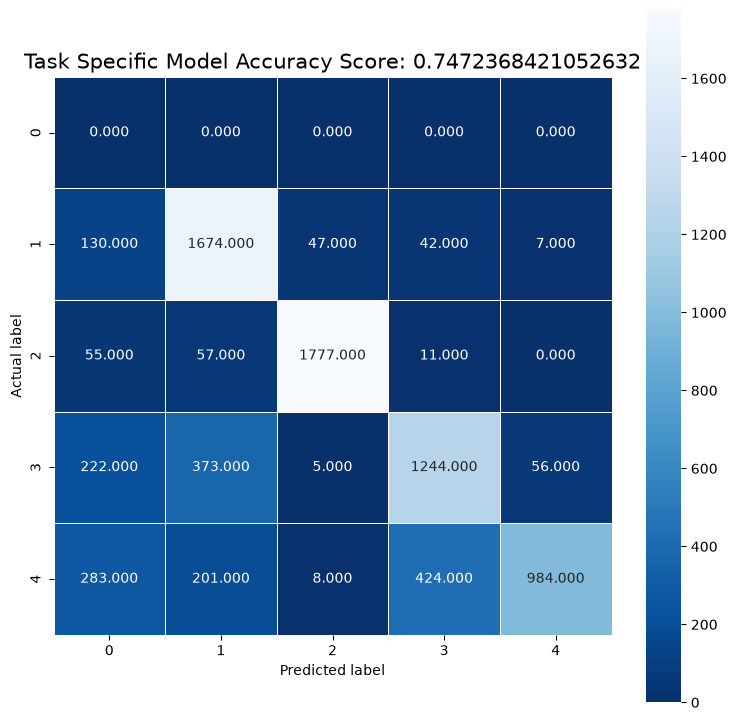

In [35]:
conf_matrix = confusion_matrix(y_val, y_pred_remapped)
acc = accuracy_score(y_val, y_pred_remapped)
macro_f1 = f1_score(y_val, y_pred_remapped, average='macro')
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'Task Specific Model Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

In [36]:
task_specific_results = pd.DataFrame([{"Method": "Task-Specific", "Accuracy": acc,  "F1-Macro": macro_f1}])
results_df = pd.concat([results_df, task_specific_results], ignore_index=True)

Even with the very imperfect mapping of topics from the 40 possible topics of the model to the 4 topics of the dataset, we see an improvement over the previous models. This is a testament to the power of fine tuning a model to a specific task. The comparison of this method would have been further improved if we were able to use a task specific model that only predicted articles as one of the four topics our data contained. Still, given that weakness of mapping this model onto our data, this is a notable improvement. 

## Method 5: Hosting a small local general LLM to predict using a prompt

We might want to test the ability of a general model to solve this problem, however, this will take much longer to run in general. To make this more practical, we will take a sample of tweets to run this on. While this does not result in a 1-to-1 comparison, we can compare it's rate of accuracy. Ultimately this is done purely to make running the code more practical.

In [37]:
sampled_articles = val_df.sample(1000, random_state=1234)

In [38]:
%%log_time Method5_LLMAcquisition
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
model.eval()
print("Model loaded!")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model loaded!


In [39]:
labels = ["world", "sports", "technology", "business"]

def classify_news(text):
    messages = [
        {"role": "system", "content": "Classify the text into exactly one category."},
        {"role": "user", "content": text}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1] #next-token logits

    best_label, best_score = None, float("-inf")
    for label in labels:
        # score = sum of log-probs of the label's tokens, conditioned on prompt
        label_ids = tokenizer(label, add_special_tokens=True).input_ids
        score = logits[label_ids[0]].item() #crude first-token score
        if score > best_score:
            best_score, best_label = score, label
    if best_label=="world":
        best_label = 1
    elif best_label=="sports":
        best_label = 2
    elif best_label=="technology":
        best_label = 3
    elif best_label=="business":
        best_label = 4
    return best_label

In [40]:
%%log_time Method5_LLMInference
y_pred_llm = [classify_news(article) for article in sampled_articles['text']]

In [41]:
y_pred_llm.count(1), y_pred_llm.count(2), y_pred_llm.count(3), y_pred_llm.count(4)

(223, 292, 68, 417)

In the future we could batch requests or find a better prompt that yields more strict and accurate results. 

Text(0.5, 1.0, 'LLM Topic Accuracy Score: 0.596')

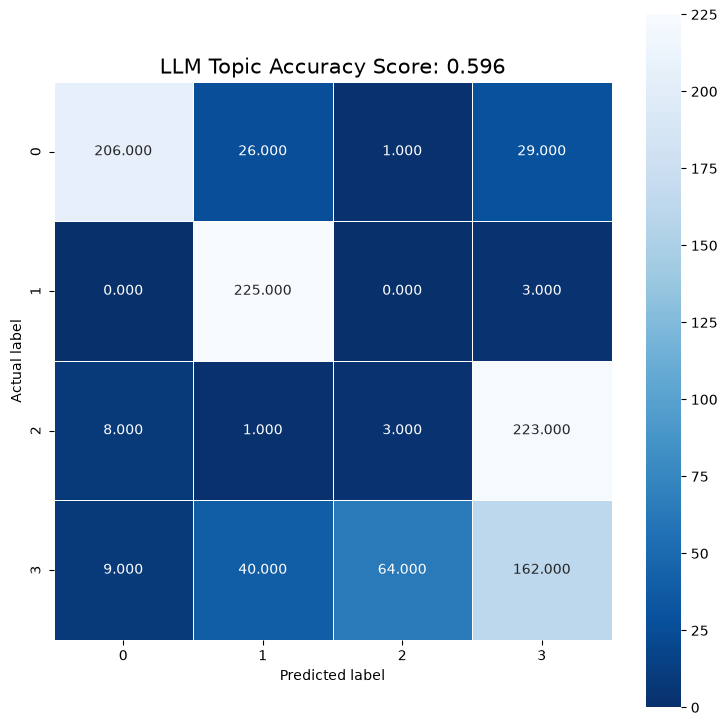

In [42]:
conf_matrix = confusion_matrix(sampled_articles['label'], y_pred_llm)
acc = accuracy_score(sampled_articles['label'], y_pred_llm)
macro_f1 = f1_score(sampled_articles['label'], y_pred_llm, average='macro')
plt.figure(figsize=(9,9))
sns.heatmap(conf_matrix, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
title = 'LLM Topic Accuracy Score: {0}'.format(acc)
plt.title(title, size = 15)

In [43]:
llm_results = pd.DataFrame([{"Method": "LLM", "Accuracy": acc,  "F1-Macro": macro_f1}])
results_df = pd.concat([results_df, llm_results], ignore_index=True)

## Results and Conclusions

In [44]:
execution_df

,Cell_Label,Execution_Time_Sec
0,Method1_BoWTraining,1.575321
1,Method1_BoWInference,0.000946
2,Method2_TFIDFTraining,2.626538
3,Method2_TFIDFInference,0.001062
4,Method3_EmbeddingTraining,96.604696
5,Method3_EmbeddingInference,0.002485
6,Method4_TaskSpecificModelAcquisition,1.209761
7,Method4_TaskSpecificModelInference,57.703766
8,Method5_LLMAcquisition,2.359757
9,Method5_LLMInference,94.651601


In [45]:
results_df

,Method,Accuracy,F1-Micro,F1-Macro
0,Bag of Words,0.450921,NaN,0.433099
1,TF-IDF,0.449737,NaN,0.432331
2,Embedding,0.714868,NaN,0.715500
3,Task-Specific,0.747237,NaN,0.620425
4,LLM,0.596,NaN,0.550720


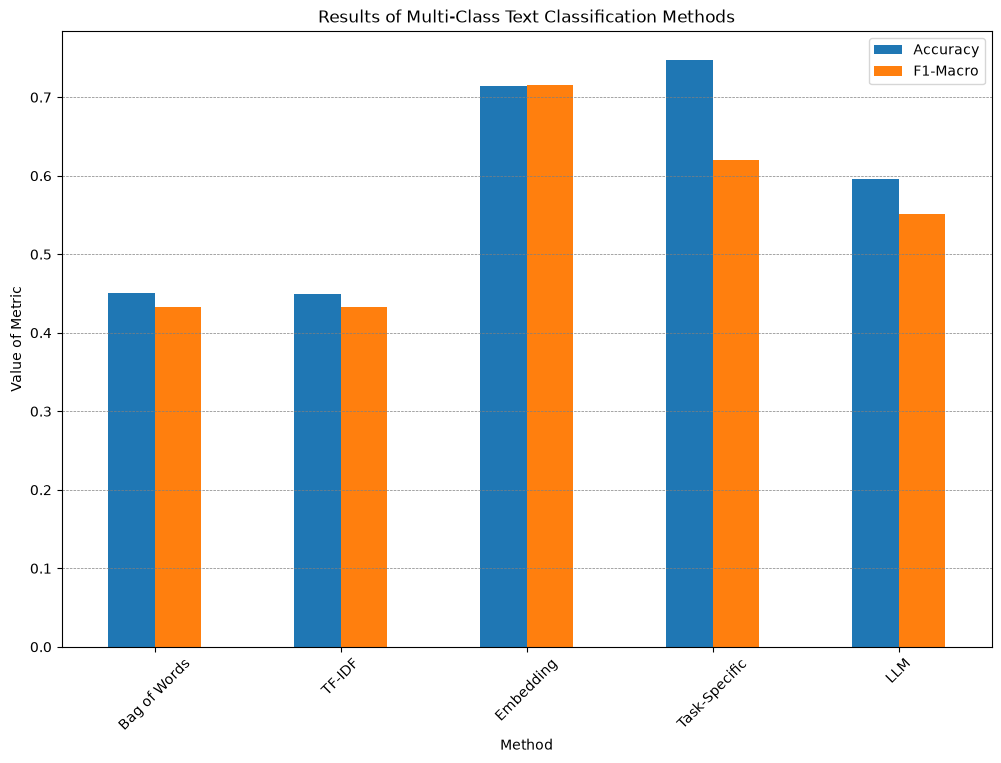

In [46]:
ax = results_df.plot(x='Method', y=['Accuracy', 'F1-Macro'], kind='bar', rot=45, figsize=(12, 8))
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.5) 
plt.title('Results of Multi-Class Text Classification Methods')
plt.ylabel('Value of Metric')
plt.show()

Phase,Inference,Training/Acquisition
Method,,
Method1 BoW,0.000946,1.575321
Method2 TFIDF,0.001062,2.626538
Method3 Embedding,0.002485,96.604696
Method4 TaskSpecificModel,57.703766,1.209761
Method5 LLM,94.651601,2.359757


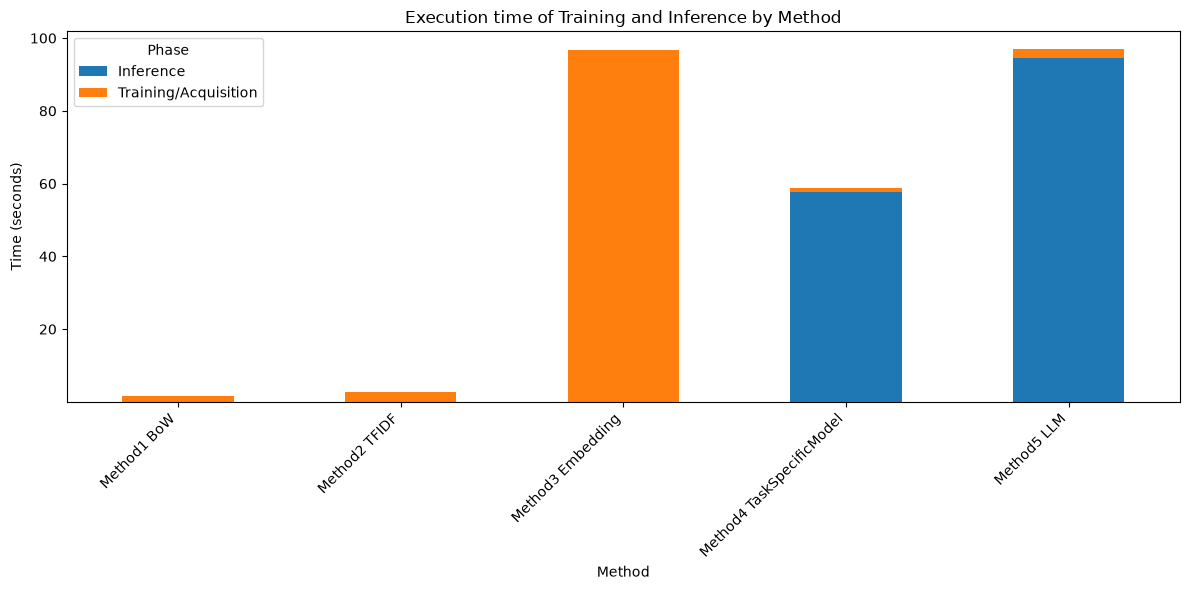

In [47]:
def classify_phase(label):
    s = str(label).lower()
    if 'infer' in s:
        return 'Inference'
    return 'Training/Acquisition'

def extract_method(label):
    label = str(label)
    cleaned = re.sub(r'(?i)(training|train|inference|infer|acquisition|acquisition|acquisi|load|download)', '', label)
    cleaned = cleaned.replace('_', ' ').strip()
    return cleaned if cleaned else label

execution_df['Phase'] = execution_df['Cell_Label'].apply(classify_phase)
execution_df['Method'] = execution_df['Cell_Label'].apply(extract_method)
execution_df['Execution_Time_Sec'] = execution_df['Execution_Time_Sec'].astype(float)

summary = execution_df.groupby(['Method','Phase'])['Execution_Time_Sec'].sum().unstack(fill_value=0)
display(summary)

ax = summary.plot(kind='bar', stacked=True, figsize=(12,6))
ax.set_ylabel('Time (seconds)')
ax.set_title('Execution time of Training and Inference by Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()